# Exploratory Data Analysis (EDA)

## Detección de fraude bancario con enfoque en establecimientos de hospedaje

Este notebook contiene la exploración inicial del dataset de transacciones bancarias basado en ISO 8583.  
El objetivo principal del análisis es comprender la estructura de los datos, evaluar el comportamiento de la variable objetivo `is_fraud` e identificar patrones relevantes para mejorar la detección de fraudes cometidos en establecimientos de hospedaje.

### Objetivos del EDA

1. Validar la calidad general del dataset.
2. Analizar la distribución de fraudes y transacciones legítimas.
3. Explorar variables financieras, temporales, geográficas y de canal.
4. Identificar patrones asociados a establecimientos de hospedaje.
5. Generar hallazgos que sirvan como base para la ingeniería de variables y modelado.

## 1. Importación de librerías y configuración inicial

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Carga del dataset


In [46]:
DATA_PATH = Path("../data/raw/01_bo_vip_seed22_n100000.csv")

df = pd.read_csv(DATA_PATH, sep=";")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Filas: 100,003
Columnas: 66


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE48_additional_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,e253ee7d060689e75077b0c7d85d995bf4ba104a7a931e...,100,5.312700e+15,0,39379,345082,101000151,87630970.0,947249,200151,1231,2901,101.0,5651,826,72,1.0,0,14484680068,531270******3773=2901201,TEBBJIQJPQP9,17P76V,0,BO-23325,M74178102540833,LEVIS STORE LONDON GB,NaN,NaN,826,68,68,N,NaN,N,NaN,1.448468e+10,POS-ATTENDED,0.0,BO-VIP,1.448468e+10,ACC774404459020,NaN,07200N,3450.82,393.79,GBP,500.12,True,8717.0,20,Tue,True,Approved,2012.51,TARIJA,False
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,9de2ffd889d660bc1d350aff8143484eaab5246c0c3f31...,100,4.212500e+15,0,1310264,1310264,101000355,10000000.0,7687,200355,1231,2907,101.0,4511,68,81,2.0,59,14484680068,421250******5552=2907201,115BVLO5H5F0,48D1XM,0,BO-34705,M95802681578714,IBERIA LAPAZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC620405269742,NaN,08159N,13102.64,13102.64,BOB,1898.93,False,4.9,20,Tue,True,Approved,1096.46,LAPAZ,False
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,14d38149e4bcdeffed96229129ba6d359b477780d24ba0...,100,5.312700e+15,0,241394,241394,101000410,10000000.0,979481,200410,1231,2610,101.0,5732,68,81,2.0,59,14484680068,531270******6104=2610201,NUKM3XFSZVJX,PFIGFD,0,BO-31334,M28333044130009,AMAZON ELECTRO SANTACRUZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC606260684104,NaN,08159N,2413.94,2413.94,BOB,349.85,False,4.4,20,Tue,True,Approved,1528.37,SANTACRUZ,False
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002587,PLATINUM,ATM,VISA,479500******0288,7ff3ca034215fd90c2019b8762e9493cc5867dff207082...,100,4.795000e+15,10000,31416,238449,101000453,75900496.0,915846,200453,1231,2710,101.0,6011,250,51,2.0,0,14484680068,479500******0288=2710201,BF4EW9A6R844,7Z9YO7,0,BO-65992,M76079092139715,ATM RED LINK PARIS FR,NaN,NaN,978,68,68,Y,NaN,Y,NaN,1.448468e+10,ATM-UNATTENDED,0.0,BO-VIP,1.448468e+10,ACC743423920527,NaN,05100Y,2384.49,314.16,EUR,345.58,True,3966.0,20,Tue,True,Approved,2483.34,SUCRE,False
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000087,PRIVATE,POS,VISA,479500******0249,bdc9c9f8a47332f4833214c4f90e7a1b88b606d52aec00...,100,4.795000e+15,0,82038,82038,101000756,10000000.0,943975,200756,1231,3004,101.0,5812,68,21,3.0,0,14484680068,479500******0249=3004201,S6QRPTMN6WAD,KL6D9H,0,BO-93457,M55941189713950,BISTRO DEL CENTRO COCHABAMBA BO,NaN,NaN,68,68,68,Y,NaN,N,NaN,1.448468e+10,POS-ATTENDED,0.0,BO-VIP,1.448468e+10,ACC988775152881,N

## 3. Revisión general del dataset

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100003 entries, 0 to 100002
Data columns (total 66 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100003 non-null  str    
 1   bank_code                         100003 non-null  str    
 2   bank_name                         100003 non-null  str    
 3   bank_country                      100003 non-null  str    
 4   bank_tier                         100003 non-null  str    
 5   client_id                         100003 non-null  str    
 6   client_segment                    98957 non-null   str    
 7   channel                           100003 non-null  str    
 8   card_brand                        98961 non-null   str    
 9   pan_masked                        100003 non-null  str    
 10  pan_hash                          100003 non-null  str    
 11  MTI                               100003 non-null  int64  
 12 

In [48]:
df.columns.tolist()

['transaction_id',
 'bank_code',
 'bank_name',
 'bank_country',
 'bank_tier',
 'client_id',
 'client_segment',
 'channel',
 'card_brand',
 'pan_masked',
 'pan_hash',
 'MTI',
 'DE2_PAN',
 'DE3_processing_code',
 'DE4_amount_transaction',
 'DE6_amount_cardholder_billing',
 'DE7_transmission_datetime',
 'DE9_conversion_rate_billing',
 'DE11_STAN',
 'DE12_local_time',
 'DE13_local_date',
 'DE14_expiration_date',
 'DE15_settlement_date',
 'DE18_merchant_category_code',
 'DE19_acquirer_country_code',
 'DE22_pos_entry_mode',
 'DE23_card_seq_number',
 'DE25_pos_condition_code',
 'DE32_acquiring_institution_id',
 'DE35_track2_data_masked',
 'DE37_retrieval_reference_number',
 'DE38_authorization_code',
 'DE39_response_code',
 'DE41_terminal_id',
 'DE42_card_acceptor_id',
 'DE43_card_acceptor_name_location',
 'DE44_additional_response_data',
 'DE48_additional_data',
 'DE49_currency_code_transaction',
 'DE50_currency_code_settlement',
 'DE51_currency_code_billing',
 'DE52_pin_data_present',
 'DE5

In [49]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,100003,100003,7dd812b1-bd03-4d05-afc6-c318dcc9b651,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bank_code,100003,1,BO-VIP,100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bank_name,100003,1,BO-VIP,100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bank_country,100003,1,BO,100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bank_tier,100003,1,vip,100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_id,100003,4000,BO-VIP-CL-00003747,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_segment,98957,4,PRIVATE,44238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,100003,4,ECOM,46312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_brand,98961,2,VISA,66149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pan_masked,100003,3735,479500******4547,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Calidad de datos

Se revisan valores nulos, columnas completamente vacías y registros duplicados.  


In [50]:
missing_summary = (
    df.isnull()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df)) * 100
missing_summary = missing_summary.sort_values("missing_pct", ascending=False)

missing_summary.head(20)

,missing_count,missing_pct
DE56_original_data,100003,100.000000
DE103_account_id_2,100003,100.000000
DE54_additional_amounts,100003,100.000000
DE48_additional_data,100003,100.000000
DE44_additional_response_data,96736,96.733098
DE38_authorization_code,3267,3.266902
DE100_receiving_institution_id,1050,1.049969
client_segment,1046,1.045969
DE63_network_specific,1045,1.044969
card_brand,1042,1.041969


In [51]:
empty_cols = df.columns[df.isnull().all()].tolist()

print("Columnas completamente vacías:")
empty_cols

Columnas completamente vacías:


['DE48_additional_data',
 'DE54_additional_amounts',
 'DE56_original_data',
 'DE103_account_id_2']

In [52]:
duplicate_count = df.duplicated().sum()

print(f"Registros duplicados: {duplicate_count}")

Registros duplicados: 0


### Limpieza inicial

Se eliminan las columnas completamente vacías, ya que no aportan información al análisis ni al modelo.

In [53]:
# Columnas a eliminar:
#  - Completamente vacías (identificadas arriba)
#  - DE44_additional_response_data: 96.7% nulos, sin valor predictivo
cols_to_drop = empty_cols + ["DE44_additional_response_data"]

df_clean = df.drop(columns=cols_to_drop)

print(f"Columnas originales:    {df.shape[1]}")
print(f"Columnas eliminadas:    {len(cols_to_drop)} → {cols_to_drop}")
print(f"Columnas tras limpieza: {df_clean.shape[1]}")


### Tratamiento de valores nulos

Los nulos de las variables relevantes se imputan antes de continuar el análisis.  
Las columnas de *data leakage* (`approved`, `DE39_response_code`, `response_description`, `DE38_authorization_code`) se conservan aquí pero serán excluidas en la etapa de modelado.


In [ ]:
# ── Numéricas: mediana ──────────────────────────────────────────────────
num_impute = [
    "distance_from_home_km",
    "DE9_conversion_rate_billing",
    "DE61_pos_extended_data",
    "DE23_card_seq_number",
    "DE15_settlement_date",
    "DE100_receiving_institution_id",
    "DE58_authorizing_agent_id",
]
for col in num_impute:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# ── Categóricas: moda ───────────────────────────────────────────────────
mode_impute = ["client_segment", "card_brand", "day_of_week", "DE63_network_specific"]
for col in mode_impute:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# ── IDs / códigos: UNKNOWN ──────────────────────────────────────────────
unknown_impute = [
    "DE123_pos_data_code", "DE42_card_acceptor_id",
    "DE102_account_id_1",  "DE41_terminal_id",
    "DE35_track2_data_masked", "DE38_authorization_code",
]
for col in unknown_impute:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('UNKNOWN')

# ── Verificar nulos restantes ────────────────────────────────────────────
remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print("Nulos restantes tras imputación:")
if len(remaining):
    print(remaining)
else:
    print("  Ninguno en columnas de modelo")


## 5. Conversión y creación de variables temporales

La variable `DE7_transmission_datetime` contiene la fecha y hora de transmisión.  
Se convierte a formato `datetime` para facilitar análisis por mes, día y hora.

In [54]:
# DE7_transmission_datetime: entero de 9 dígitos en formato M/MMDDHHmmss
# Se hace zero-pad a 10 caracteres y se parsea como %m%d%H%M%S
df_clean["transaction_datetime"] = pd.to_datetime(
    df_clean["DE7_transmission_datetime"].astype(str).str.zfill(10),
    format="%m%d%H%M%S",
    errors="coerce"
)

nat_count = df_clean["transaction_datetime"].isna().sum()
ok_count  = df_clean["transaction_datetime"].notna().sum()
print(f"Fechas parseadas correctamente: {ok_count:,}")
print(f"NaT (error de parseo):          {nat_count:,}")
print(f"Meses en el dataset: {sorted(df_clean['transaction_datetime'].dt.month.dropna().unique().astype(int))}")

df_clean[["DE7_transmission_datetime", "transaction_datetime"]].head()


In [55]:
df_clean["transaction_month"] = df_clean["transaction_datetime"].dt.month
df_clean["transaction_day"] = df_clean["transaction_datetime"].dt.day
df_clean["transaction_date"] = df_clean["transaction_datetime"].dt.date

df_clean[["transaction_datetime", "transaction_month", "transaction_day", "hour_local", "day_of_week"]].head()

## 6. Análisis de la variable objetivo: `is_fraud`

La variable `is_fraud` indica si una transacción fue fraudulenta (`True`) o legítima (`False`).  
En problemas de fraude suele existir un fuerte desbalance de clases.

In [56]:
target_counts = df_clean["is_fraud"].value_counts()
target_pct = df_clean["is_fraud"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

target_summary

,count,percentage
is_fraud,,
False,95084,95.081148
True,4919,4.918852


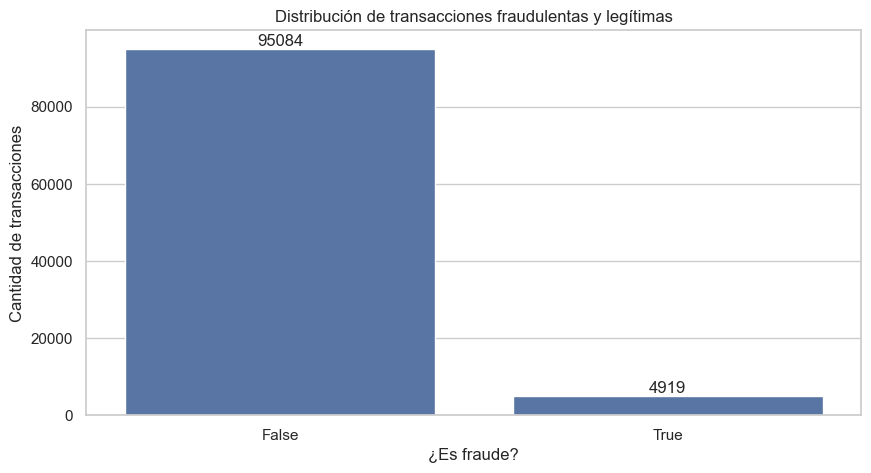

In [57]:
ax = sns.countplot(data=df_clean, x="is_fraud")

plt.title("Distribución de transacciones fraudulentas y legítimas")
plt.xlabel("¿Es fraude?")
plt.ylabel("Cantidad de transacciones")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


La clase fraudulenta representa una proporción pequeña del dataset, por lo que el problema debe tratarse como clasificación desbalanceada.  Por esta razón, métricas como accuracy no son suficientes y se deben priorizar métricas como precision, recall, F1, AUC y ratio de falsos positivos.

## 7. Análisis de montos

Se analizan los montos de transacción en USD y su relación con la variable de fraude.

In [58]:
df_clean["amount_usd"].describe()

count    100003.000000
mean        430.610978
std         597.896042
min           0.070000
25%          84.250000
50%         200.430000
75%         483.935000
max        6731.900000
Name: amount_usd, dtype: float64

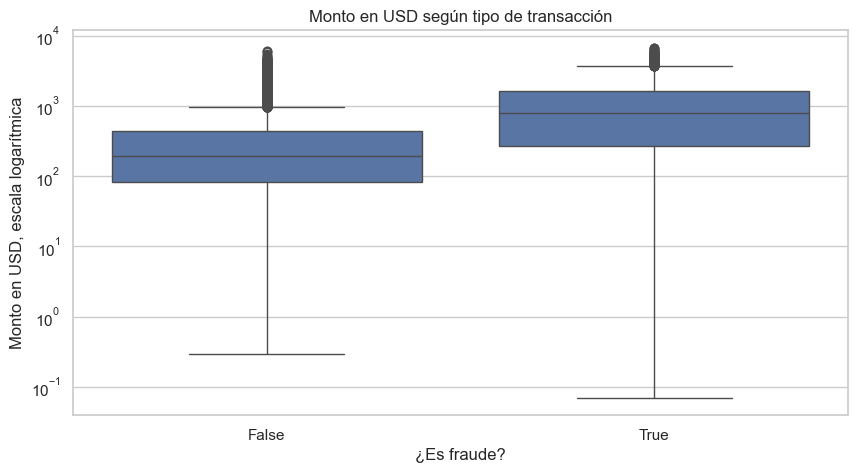

In [59]:
sns.boxplot(data=df_clean, x="is_fraud", y="amount_usd")

plt.yscale("log")
plt.title("Monto en USD según tipo de transacción")
plt.xlabel("¿Es fraude?")
plt.ylabel("Monto en USD, escala logarítmica")

plt.show()

In [60]:
amount_summary = (
    df_clean.groupby("is_fraud")["amount_usd"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

amount_summary

,count,mean,median,std,min,max
is_fraud,,,,,,
False,95084,395.912897,191.985,541.171825,0.29,6109.47
True,4919,1101.322976,788.660,1064.673918,0.07,6731.90


## 8. Análisis temporal

Se exploran patrones por hora local, día de la semana y mes.  
Esto puede revelar momentos donde el fraude ocurre con mayor frecuencia.

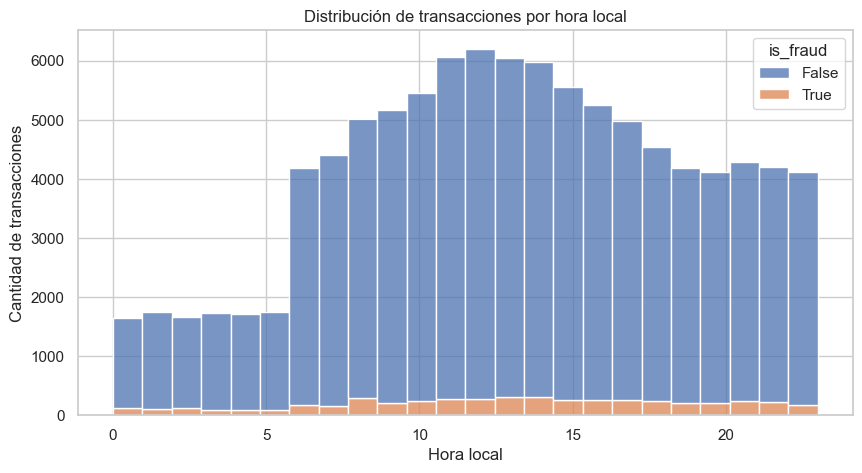

In [61]:
sns.histplot(
    data=df_clean,
    x="hour_local",
    hue="is_fraud",
    bins=24,
    multiple="stack"
)

plt.title("Distribución de transacciones por hora local")
plt.xlabel("Hora local")
plt.ylabel("Cantidad de transacciones")

plt.show()

In [62]:
fraud_by_hour = (
    df_clean.groupby("hour_local")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .reset_index()
)

fraud_by_hour["fraud_rate_pct"] = fraud_by_hour["fraud_rate"] * 100
fraud_by_hour.head()

,hour_local,total_txn,fraud_count,fraud_rate,fraud_rate_pct
0,0,1640,128,0.078049,7.804878
1,1,1754,103,0.058723,5.872292
2,2,1658,121,0.072979,7.297949
3,3,1738,94,0.054085,5.408516
4,4,1718,83,0.048312,4.831199


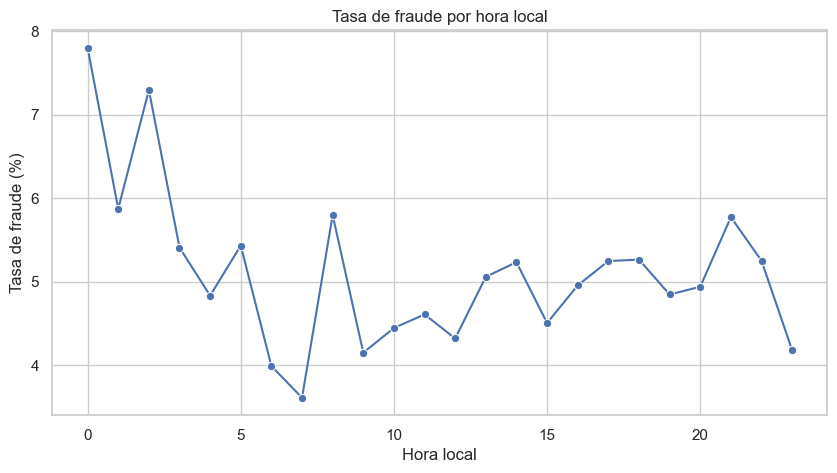

In [63]:
sns.lineplot(data=fraud_by_hour, x="hour_local", y="fraud_rate_pct", marker="o")

plt.title("Tasa de fraude por hora local")
plt.xlabel("Hora local")
plt.ylabel("Tasa de fraude (%)")

plt.show()

In [64]:
day_summary = (
    df_clean.groupby("day_of_week")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

day_summary["fraud_rate_pct"] = day_summary["fraud_rate"] * 100
day_summary

,total_txn,fraud_count,fraud_rate,fraud_rate_pct
day_of_week,,,,
Wed,14450,791,0.054740,5.474048
Sat,14447,784,0.054267,5.426732
Fri,14203,727,0.051186,5.118637
Mon,13836,660,0.047702,4.770165
Thu,14281,675,0.047266,4.726560
Tue,13805,645,0.046722,4.672220
Sun,13976,578,0.041357,4.135661


In [65]:
month_summary = (
    df_clean.groupby("transaction_month")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
)

month_summary["fraud_rate_pct"] = month_summary["fraud_rate"] * 100
month_summary

## 9. Análisis geográfico

Se analizan variables relacionadas con internacionalidad y distancia desde el hogar del cliente.  
Estas variables son especialmente relevantes para fraude en comercios de hospedaje.

In [66]:
international_summary = pd.crosstab(
    df_clean["is_international"],
    df_clean["is_fraud"],
    normalize="index"
) * 100

international_summary

is_fraud,False,True
is_international,,
False,96.165199,3.834801
True,91.540463,8.459537


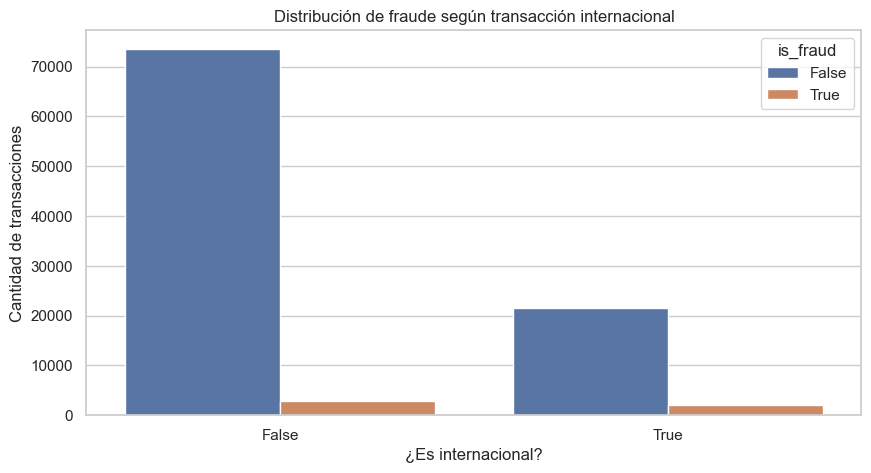

In [67]:
sns.countplot(data=df_clean, x="is_international", hue="is_fraud")

plt.title("Distribución de fraude según transacción internacional")
plt.xlabel("¿Es internacional?")
plt.ylabel("Cantidad de transacciones")

plt.show()

In [68]:
distance_summary = (
    df_clean.groupby("is_fraud")["distance_from_home_km"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

distance_summary

,count,mean,median,std,min,max
is_fraud,,,,,,
False,94158,1720.966043,20.7,3183.043073,0.0,12000.0
True,4867,2894.742593,782.0,3690.127133,0.0,11991.0


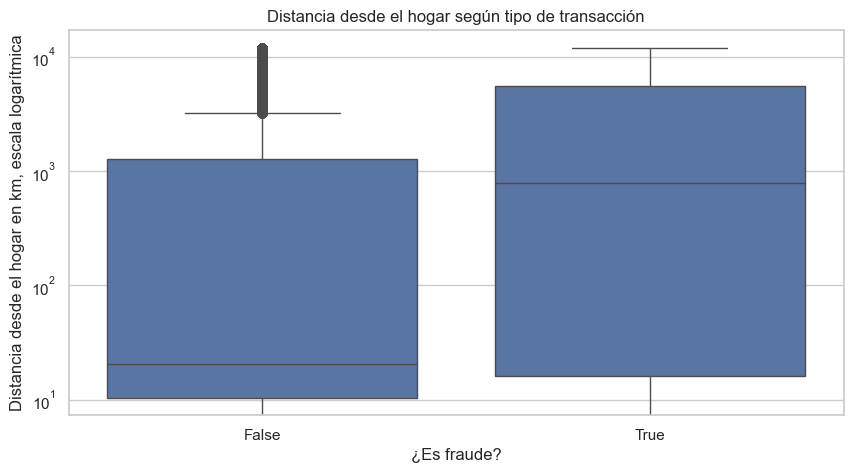

In [69]:
sns.boxplot(data=df_clean, x="is_fraud", y="distance_from_home_km")

plt.yscale("log")
plt.title("Distancia desde el hogar según tipo de transacción")
plt.xlabel("¿Es fraude?")
plt.ylabel("Distancia desde el hogar en km, escala logarítmica")

plt.show()

## 10. Análisis por canal y punto de venta

Se revisan variables relacionadas con el canal, modo de entrada POS y condición del POS.  
Estas variables ayudan a diferenciar transacciones presenciales, manuales, contactless o e-commerce.

In [70]:
channel_summary = (
    df_clean.groupby("channel")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

channel_summary["fraud_rate_pct"] = channel_summary["fraud_rate"] * 100
channel_summary

,total_txn,fraud_count,fraud_rate,fraud_rate_pct
channel,,,,
ECOM,46312,3715,0.080217,8.021679
ATM,9725,276,0.028380,2.838046
POS,39128,877,0.022414,2.241362
MOTO,4838,51,0.010542,1.054155


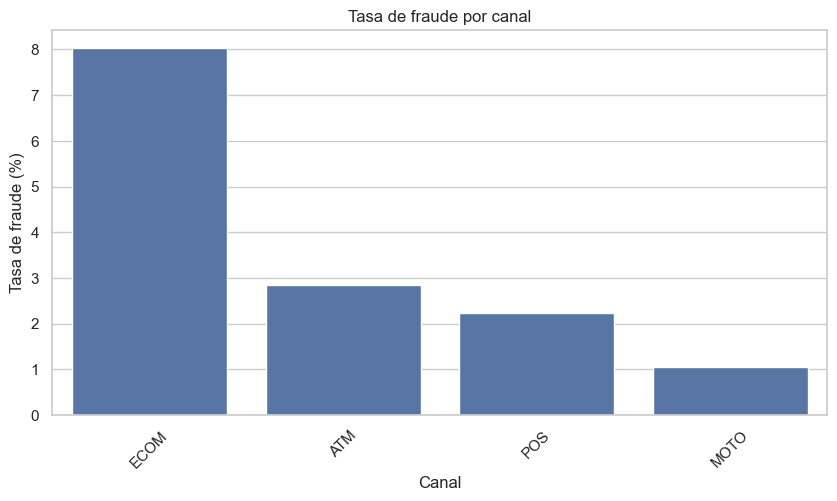

In [71]:
sns.barplot(
    data=channel_summary.reset_index(),
    x="channel",
    y="fraud_rate_pct"
)

plt.title("Tasa de fraude por canal")
plt.xlabel("Canal")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(rotation=45)

plt.show()

In [72]:
pos_entry_summary = (
    df_clean.groupby("DE22_pos_entry_mode")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

pos_entry_summary["fraud_rate_pct"] = pos_entry_summary["fraud_rate"] * 100
pos_entry_summary

,total_txn,fraud_count,fraud_rate,fraud_rate_pct
DE22_pos_entry_mode,,,,
22,189,186,0.984127,98.412698
81,46312,3715,0.080217,8.021679
71,6129,305,0.049763,4.976342
51,30427,535,0.017583,1.758307
72,5814,62,0.010664,1.066391
10,6012,63,0.010479,1.047904
21,5120,53,0.010352,1.035156


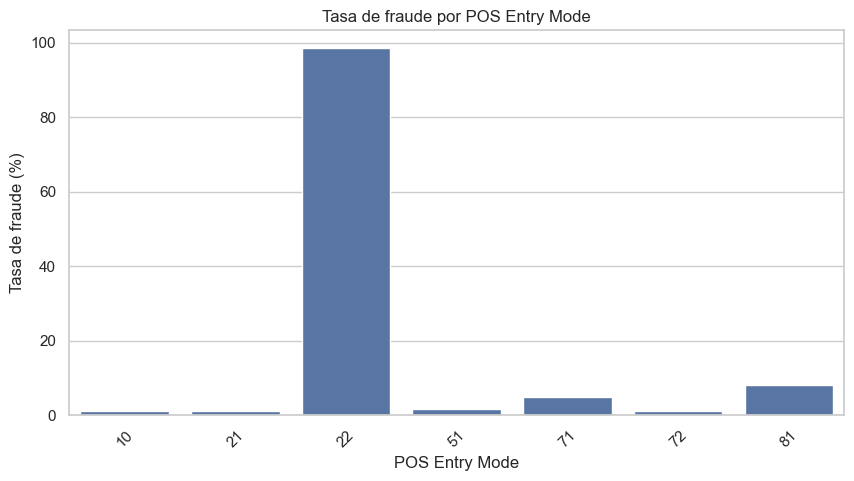

In [73]:
sns.barplot(
    data=pos_entry_summary.reset_index(),
    x="DE22_pos_entry_mode",
    y="fraud_rate_pct"
)

plt.title("Tasa de fraude por POS Entry Mode")
plt.xlabel("POS Entry Mode")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(rotation=45)

plt.show()

In [74]:
pos_condition_summary = (
    df_clean.groupby("DE25_pos_condition_code")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

pos_condition_summary["fraud_rate_pct"] = pos_condition_summary["fraud_rate"] * 100
pos_condition_summary

,total_txn,fraud_count,fraud_rate,fraud_rate_pct
DE25_pos_condition_code,,,,
59,46312,3715,0.080217,8.021679
0,47679,1141,0.023931,2.393087
8,4838,51,0.010542,1.054155
1,1174,12,0.010221,1.022147


## 11. Análisis por MCC

El `DE18_merchant_category_code` representa el giro o categoría del comercio.  
Esta variable es clave para el proyecto, ya que el objetivo específico del grupo es mejorar la detección de fraude en establecimientos de hospedaje.

In [75]:
mcc_summary = (
    df_clean.groupby("DE18_merchant_category_code")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

mcc_summary["fraud_rate_pct"] = mcc_summary["fraud_rate"] * 100
mcc_summary.head(20)

,total_txn,fraud_count,fraud_rate,fraud_rate_pct
DE18_merchant_category_code,,,,
6051,328,326,0.993902,99.390244
7995,340,337,0.991176,99.117647
5969,2234,453,0.202775,20.277529
4816,5106,621,0.121622,12.162162
5967,5979,633,0.105871,10.587055
5944,4918,373,0.075844,7.584384
5732,11018,666,0.060447,6.044654
7011,9064,415,0.045786,4.578553
4511,9192,414,0.045039,4.503916


In [76]:
top_mcc_by_volume = (
    df_clean["DE18_merchant_category_code"]
    .value_counts()
    .head(20)
)

top_mcc_by_volume

DE18_merchant_category_code
5732    11018
6011     9725
4511     9192
7011     9064
5311     7863
5651     7697
5967     5979
4816     5106
5944     4918
5812     4526
5921     3367
5999     2582
7832     2383
5814     2363
5193     2310
5969     2234
4814     1818
5912     1220
4111     1171
5541     1140
Name: count, dtype: int64

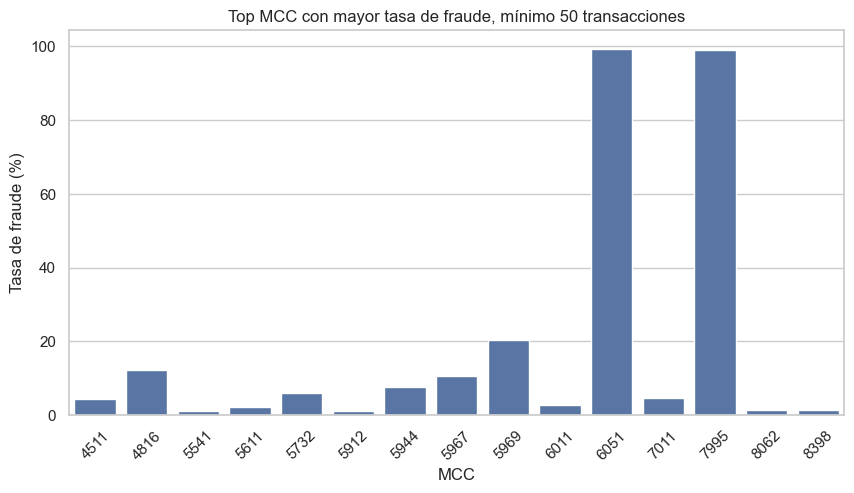

In [77]:
top_mcc = mcc_summary[mcc_summary["total_txn"] >= 50].head(15).reset_index()

sns.barplot(
    data=top_mcc,
    x="DE18_merchant_category_code",
    y="fraud_rate_pct"
)

plt.title("Top MCC con mayor tasa de fraude, mínimo 50 transacciones")
plt.xlabel("MCC")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(rotation=45)

plt.show()

## 12. Enfoque específico: establecimientos de hospedaje

Para aproximar transacciones relacionadas con hospedaje se utiliza una regla basada en MCC.

### Criterio utilizado

- MCC 3501–3999: hoteles y cadenas de alojamiento.
- MCC 7011: hoteles, moteles y resorts.

Esta regla puede ajustarse si se dispone de un catálogo MCC más específico del dataset.

In [78]:
hotel_mccs = list(range(3501, 4000)) + [7011]

df_clean["is_hotel"] = df_clean["DE18_merchant_category_code"].isin(hotel_mccs)

hotel_summary = df_clean["is_hotel"].value_counts().to_frame("count")
hotel_summary["percentage"] = (hotel_summary["count"] / len(df_clean)) * 100

hotel_summary

,count,percentage
is_hotel,,
False,90939,90.936272
True,9064,9.063728


In [79]:
hotel_fraud_summary = pd.crosstab(
    df_clean["is_hotel"],
    df_clean["is_fraud"],
    normalize="index"
) * 100

hotel_fraud_summary

is_fraud,False,True
is_hotel,,
False,95.047229,4.952771
True,95.421447,4.578553


In [80]:
hotel_df = df_clean[df_clean["is_hotel"]].copy()

print(f"Transacciones de hospedaje: {hotel_df.shape[0]:,}")
print(f"Columnas: {hotel_df.shape[1]:,}")

hotel_df.head()

Transacciones de hospedaje: 9,064
Columnas: 67


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE55_emv_data_present,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud,transaction_datetime,transaction_month,transaction_day,transaction_date,is_hotel
10,251f68c0-20ea-41ce-a8f3-760d54d95e7c,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00003579,PRIVATE,ECOM,VISA,479500******5152,fb2f51e9cf7aaf83a61e458a6e48aadd3b871fe6e7506a...,100,4.795000e+15,0,59301,409177,101001821,69000016.0,912838,201821,1231,3001,101.0,7011,840,81,1.0,59,14484680068,479500******5152=3001201,YC48MLZWT47C,AD68HK,0,BO-04606,M92653765654587,HOTEL HILTON ORLANDO US,NaN,840,68,68,N,N,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC675039512499,08159N,4091.77,593.01,USD,593.01,True,8180.0,20,Tue,True,Approved,1328.00,SUCRE,False,NaT,NaN,NaN,NaT,True
35,c8a975d2-e4fa-4232-a836-58f43290b574,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001474,BLACK,ECOM,VISA,479500******4078,34abc2653adb41c44f90ebbedd62130cdfc5c711fdd0e5...,100,4.795010e+15,0,859581,859581,101012431,10000000.0,5973,212431,1231,2805,101.0,7011,68,81,2.0,59,14484680068,479500******4078=2805201,YLWR9WSI0NY9,HB35WU,0,BO-22111,M86893079730011,HOTEL PRESIDENTE ORURO BO,NaN,68,68,68,N,N,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,NaN,ACC956611530622,08159N,8595.81,8595.81,BOB,1245.77,False,4.1,21,Tue,True,Approved,1828.43,ORURO,False,1010-01-02 04:03:01,1.0,2.0,1010-01-02,True
43,e9b2d7cd-0219-4f8c-84fc-ddd639c7419d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00003407,PLATINUM,ECOM,VISA,479500******9111,d08c892829a832c9052308778abf17b0fec31564318fe9...,100,4.795010e+15,0,702238,702238,101014640,10000000.0,935393,214640,1231,2812,101.0,7011,68,81,1.0,59,14484680068,479500******9111=2812201,09HO4DV9PI15,EQSN88,0,BO-59148,M98861166989350,HYATT INN TARIJA BO,NaN,68,68,68,N,N,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC575350818649,08159N,7022.38,7022.38,BOB,1017.74,False,14.9,21,Tue,True,Approved,2447.50,TARIJA,False,1010-01-04 06:04:00,1.0,4.0,1010-01-04,True
80,23244912-404f-47d6-b7a9-71876db0bdda,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001915,PRIVATE,ECOM,VISA,421250******5726,4f22a71be4c427982f84f1b283fdbb343b49131492b423...,100,4.212510e+15,0,2338,2338,101031145,10000000.0,7719,231145,1231,2612,101.0,7011,68,81,2.0,59,14484680068,421250******5726=2612201,3OQQVUO216IS,Z3PMYA,0,BO-65504,M54348995372724,HOTEL PRESIDENTE POTOSI BO,NaN,68,68,68,N,N,1.448468e+10,ECOM-VIRTUAL,59.0,BO-VIP,1.448468e+10,ACC639102174046,08159N,23.38,23.38,BOB,3.39,False,12.1,23,Tue,True,Approved,717.49,POTOSI,False,1010-03-01 01:04:05,3.0,1.0,1010-03-01,True
81,620014e3-e08a-47d6-9366-65b699f28f5a,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002959,BLACK,ECOM,VISA,479500******0627,a08b49a54bec4e0f46b8c7b60a56767077e77919270345...,100,4.795000e+15,0,107892,945459,101031457,87630130.0,986191,231457,1231,2905,101.0,7011,826,81,1.0,59,14484680068,479500******0627=2905201,1HPT9BKS4927,UWH2I0,0,BO-35007,M11739247161427,HOTEL PRESIDENTE LONDON GB,NaN,826,68,68,N,N,1.448468e+10,ECO

## 13. Análisis de fraude en hospedaje

Esta sección analiza si los establecimientos de hospedaje presentan patrones diferenciados frente al resto de transacciones.

In [81]:
hotel_target_summary = pd.DataFrame({
    "count": hotel_df["is_fraud"].value_counts(),
    "percentage": hotel_df["is_fraud"].value_counts(normalize=True) * 100
})

hotel_target_summary

,count,percentage
is_fraud,,
False,8649,95.421447
True,415,4.578553


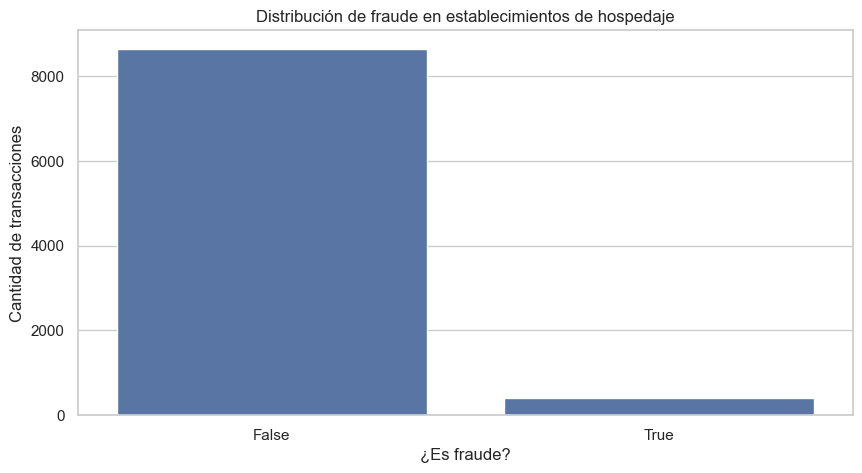

In [82]:
sns.countplot(data=hotel_df, x="is_fraud")

plt.title("Distribución de fraude en establecimientos de hospedaje")
plt.xlabel("¿Es fraude?")
plt.ylabel("Cantidad de transacciones")

plt.show()

In [83]:
hotel_amount_summary = (
    hotel_df.groupby("is_fraud")["amount_usd"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

hotel_amount_summary

,count,mean,median,std,min,max
is_fraud,,,,,,
False,8649,907.329658,811.87,558.327012,0.29,3545.27
True,415,1356.735904,1219.05,847.779695,24.47,3974.49


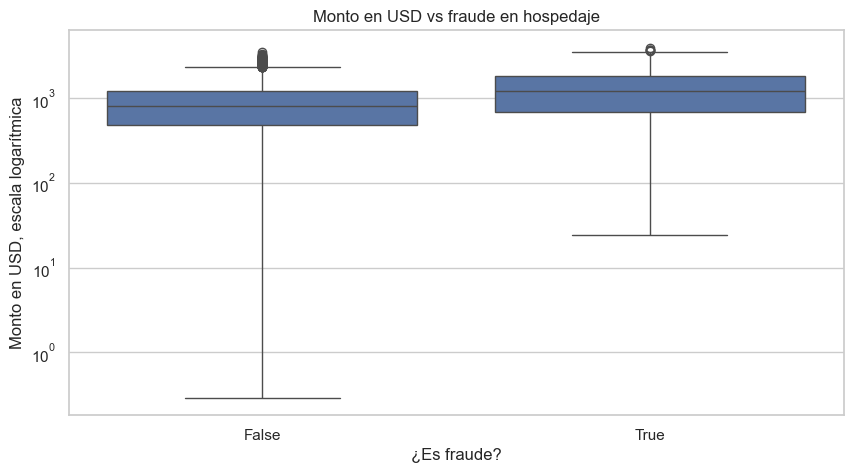

In [84]:
sns.boxplot(data=hotel_df, x="is_fraud", y="amount_usd")

plt.yscale("log")
plt.title("Monto en USD vs fraude en hospedaje")
plt.xlabel("¿Es fraude?")
plt.ylabel("Monto en USD, escala logarítmica")

plt.show()

In [85]:
hotel_international_summary = pd.crosstab(
    hotel_df["is_international"],
    hotel_df["is_fraud"],
    normalize="index"
) * 100

hotel_international_summary

is_fraud,False,True
is_international,,
False,97.447796,2.552204
True,88.976015,11.023985


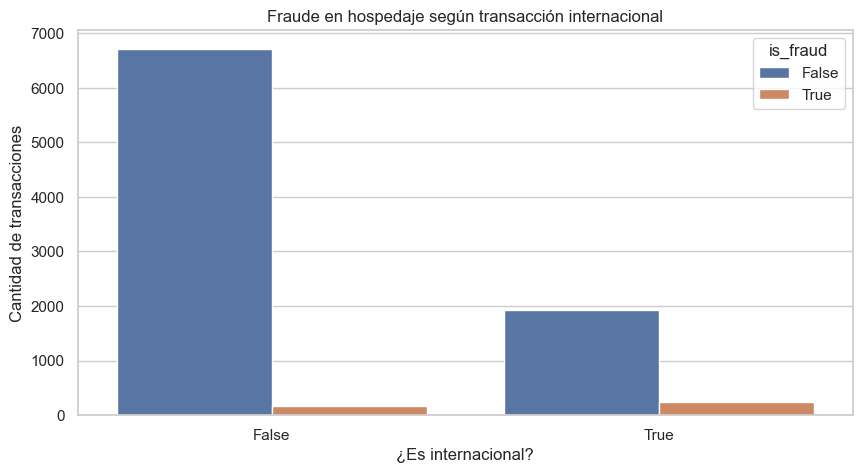

In [86]:
sns.countplot(data=hotel_df, x="is_international", hue="is_fraud")

plt.title("Fraude en hospedaje según transacción internacional")
plt.xlabel("¿Es internacional?")
plt.ylabel("Cantidad de transacciones")

plt.show()

In [87]:
hotel_channel_summary = (
    hotel_df.groupby("channel")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

hotel_channel_summary["fraud_rate_pct"] = hotel_channel_summary["fraud_rate"] * 100
hotel_channel_summary

,total_txn,fraud_count,fraud_rate,fraud_rate_pct
channel,,,,
POS,108,108,1.000000,100.000000
ECOM,7450,290,0.038926,3.892617
MOTO,1506,17,0.011288,1.128818


In [88]:
hotel_pos_entry_summary = (
    hotel_df.groupby("DE22_pos_entry_mode")["is_fraud"]
    .agg(total_txn="count", fraud_count="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

hotel_pos_entry_summary["fraud_rate_pct"] = hotel_pos_entry_summary["fraud_rate"] * 100
hotel_pos_entry_summary

,total_txn,fraud_count,fraud_rate,fraud_rate_pct
DE22_pos_entry_mode,,,,
51,53,53,1.000000,100.000000
71,55,55,1.000000,100.000000
81,7450,290,0.038926,3.892617
10,1506,17,0.011288,1.128818


In [89]:
hotel_distance_summary = (
    hotel_df.groupby("is_fraud")["distance_from_home_km"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

hotel_distance_summary

,count,mean,median,std,min,max
is_fraud,,,,,,
False,8557,1683.710424,20.6,3146.804212,0.0,11997.0
True,414,3951.430676,3131.5,3731.632444,0.8,11925.0


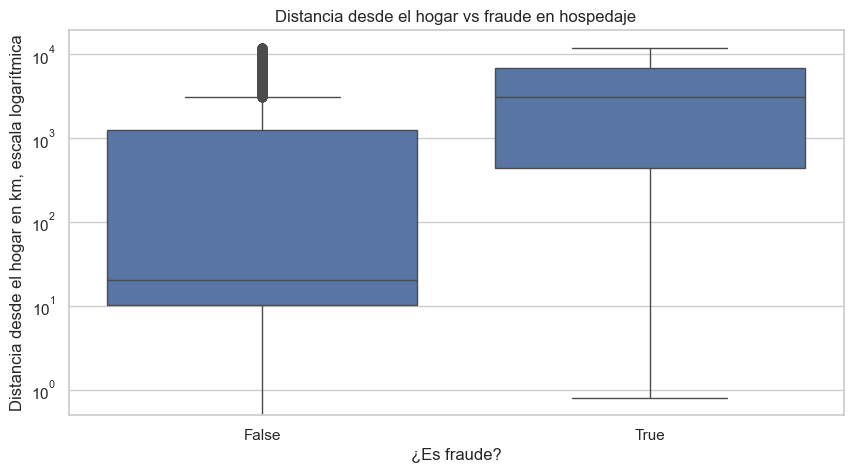

In [90]:
sns.boxplot(data=hotel_df, x="is_fraud", y="distance_from_home_km")

plt.yscale("log")
plt.title("Distancia desde el hogar vs fraude en hospedaje")
plt.xlabel("¿Es fraude?")
plt.ylabel("Distancia desde el hogar en km, escala logarítmica")

plt.show()

## 14. Variables potenciales para ingeniería de características

A partir del EDA, se identifican variables con potencial para el modelado:

- `amount_usd`: monto de la transacción.
- `is_international`: indica si el comercio está fuera del país del cliente.
- `distance_from_home_km`: distancia entre hogar del cliente y comercio.
- `hour_local`: hora local de la transacción.
- `DE18_merchant_category_code`: categoría del comercio.
- `DE22_pos_entry_mode`: modo de entrada de la tarjeta.
- `DE25_pos_condition_code`: condición del POS.
- `channel`: canal de la transacción.
- `client_baseline_amount`: monto base del comportamiento del cliente.
- `is_hotel`: variable derivada para establecimientos de hospedaje.

También se recomienda crear variables adicionales como:

- Diferencia entre `amount_usd` y `client_baseline_amount`.
- Ratio entre monto actual y monto base del cliente.
- Indicador de transacción internacional en hospedaje.
- Indicador de distancia alta en hospedaje.
- Indicador de horarios poco frecuentes.

In [91]:
df_clean["amount_vs_baseline"] = df_clean["amount_usd"] - df_clean["client_baseline_amount"]

df_clean["amount_baseline_ratio"] = np.where(
    df_clean["client_baseline_amount"] > 0,
    df_clean["amount_usd"] / df_clean["client_baseline_amount"],
    np.nan
)

df_clean["hotel_international"] = df_clean["is_hotel"] & df_clean["is_international"]

df_clean["hotel_high_distance"] = (
    df_clean["is_hotel"] &
    (df_clean["distance_from_home_km"] > df_clean["distance_from_home_km"].quantile(0.75))
)

df_clean[[
    "amount_usd",
    "client_baseline_amount",
    "amount_vs_baseline",
    "amount_baseline_ratio",
    "is_hotel",
    "hotel_international",
    "hotel_high_distance",
    "is_fraud"
]].head()

,amount_usd,client_baseline_amount,amount_vs_baseline,amount_baseline_ratio,is_hotel,hotel_international,hotel_high_distance,is_fraud
0,500.12,2012.51,-1512.39,0.248506,False,False,False,False
1,1898.93,1096.46,802.47,1.731873,False,False,False,False
2,349.85,1528.37,-1178.52,0.228904,False,False,False,False
3,345.58,2483.34,-2137.76,0.139159,False,False,False,False
4,118.90,1334.55,-1215.65,0.089094,False,False,False,False


## 15. Correlación con la variable objetivo

En lugar de analizar una matriz completa de correlación, se revisa la correlación de variables numéricas con `is_fraud`.  
Esto facilita identificar variables que podrían aportar al modelo.

In [92]:
numeric_df = df_clean.select_dtypes(include=["int64", "float64", "bool"])

corr_with_target = (
    numeric_df.corr(numeric_only=True)["is_fraud"]
    .sort_values(ascending=False)
)

corr_with_target

is_fraud                          1.000000
amount_baseline_ratio             0.279558
amount_local                      0.255151
DE6_amount_cardholder_billing     0.255151
amount_usd                        0.255151
DE39_response_code                0.222214
amount_vs_baseline                0.220386
DE61_pos_extended_data            0.132335
DE25_pos_condition_code           0.132277
DE22_pos_entry_mode               0.104792
amount_tx_currency                0.096561
DE4_amount_transaction            0.096561
is_international                  0.090592
DE49_currency_code_transaction    0.081923
distance_from_home_km             0.078808
DE19_acquirer_country_code        0.075251
DE9_conversion_rate_billing       0.071915
hotel_international               0.042024
hotel_high_distance               0.041254
DE18_merchant_category_code       0.034855
DE23_card_seq_number              0.008503
DE2_PAN                           0.003817
DE14_expiration_date              0.002886
transaction

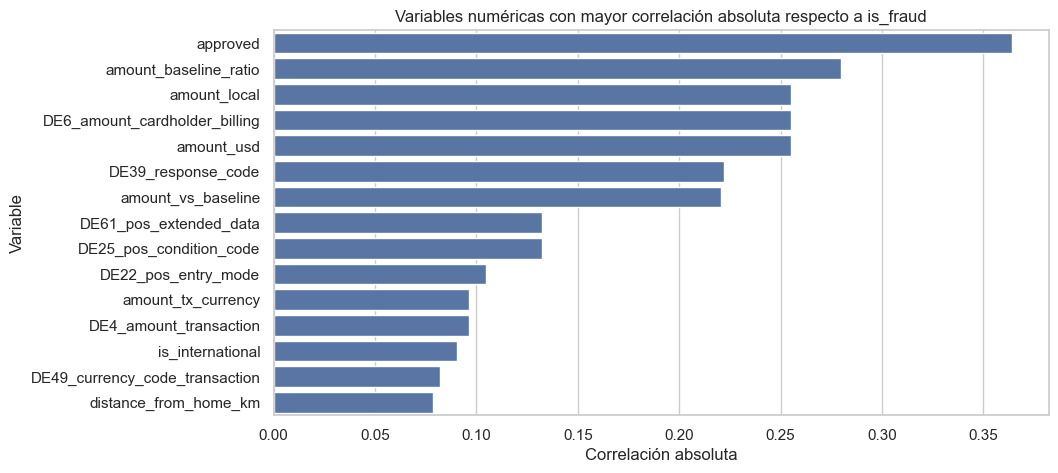

In [93]:
top_corr = corr_with_target.drop("is_fraud").abs().sort_values(ascending=False).head(15)

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Variables numéricas con mayor correlación absoluta respecto a is_fraud")
plt.xlabel("Correlación absoluta")
plt.ylabel("Variable")

plt.show()

## 16. Variables que deben tratarse con cuidado

Algunas variables pueden introducir fuga de información (*data leakage*) si se usan directamente en el modelo:

- `approved`
- `DE39_response_code`
- `response_description`
- `DE38_authorization_code`

Estas variables pueden reflejar decisiones posteriores al proceso de autorización o respuestas del sistema.  
Se pueden usar para análisis exploratorio, pero deben evaluarse cuidadosamente antes de incluirse en el modelo.

## 17. Resumen de hallazgos principales

El análisis exploratorio permitió identificar diversos patrones relevantes para la detección de fraude financiero.

En primer lugar, se observó un fuerte desbalance de clases, donde las transacciones fraudulentas representan únicamente una pequeña proporción del dataset. Esto confirma la necesidad de utilizar métricas especializadas para evaluación del modelo, evitando depender únicamente de accuracy.

Respecto a los montos, las transacciones fraudulentas presentan una mayor dispersión y valores extremos más altos que las transacciones legítimas, especialmente en operaciones internacionales y relacionadas con hospedaje.

Las transacciones internacionales muestran una mayor incidencia de fraude en comparación con las nacionales. Asimismo, la distancia desde el hogar del cliente parece relacionarse con comportamiento fraudulento, ya que las transacciones fraudulentas tienden a ocurrir a mayores distancias geográficas.

En el análisis por canal y POS Entry Mode se identificaron modos de captura con tasas de fraude superiores, particularmente operaciones relacionadas con e-commerce y transacciones no presenciales.

El análisis de MCC permitió detectar categorías comerciales con mayores tasas de fraude. Entre ellas destacan comercios asociados a hospedaje, lo cual es consistente con el objetivo específico del proyecto.

Finalmente, las transacciones relacionadas con establecimientos de hospedaje presentan patrones diferenciados en términos de internacionalidad, montos y distancia geográfica, por lo que se considera relevante desarrollar variables especializadas para este segmento durante la etapa de feature engineering.

## 18. Guardado del dataset explorado

Se guarda una versión preliminar del dataset con variables derivadas básicas para ser utilizada en la siguiente etapa de ingeniería de características.

In [94]:
OUTPUT_PATH = Path("../data/processed/eda_base_dataset.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset guardado en: {OUTPUT_PATH}")

Dataset guardado en: ..\data\processed\eda_base_dataset.csv


In [95]:
numeric_df = df_clean.select_dtypes(
    include=["int64", "float64", "bool"]
)

corr_target = (
    numeric_df.corr(numeric_only=True)["is_fraud"]
    .sort_values(ascending=False)
)

corr_target

is_fraud                          1.000000
amount_baseline_ratio             0.279558
amount_local                      0.255151
DE6_amount_cardholder_billing     0.255151
amount_usd                        0.255151
DE39_response_code                0.222214
amount_vs_baseline                0.220386
DE61_pos_extended_data            0.132335
DE25_pos_condition_code           0.132277
DE22_pos_entry_mode               0.104792
amount_tx_currency                0.096561
DE4_amount_transaction            0.096561
is_international                  0.090592
DE49_currency_code_transaction    0.081923
distance_from_home_km             0.078808
DE19_acquirer_country_code        0.075251
DE9_conversion_rate_billing       0.071915
hotel_international               0.042024
hotel_high_distance               0.041254
DE18_merchant_category_code       0.034855
DE23_card_seq_number              0.008503
DE2_PAN                           0.003817
DE14_expiration_date              0.002886
transaction

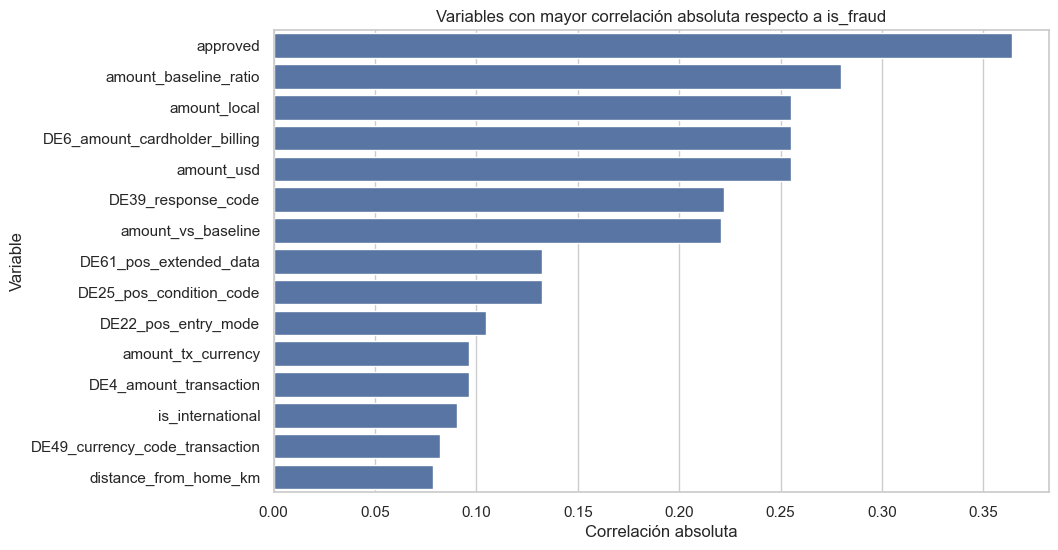

In [96]:
top_corr = (
    corr_target
    .drop("is_fraud")
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title(
    "Variables con mayor correlación absoluta respecto a is_fraud"
)

plt.xlabel("Correlación absoluta")
plt.ylabel("Variable")

plt.show()

## 19. Separación temporal de entrenamiento y testing

Siguiendo las indicaciones del proyecto, el mes de Junio 2025 será reservado como conjunto de testing final.

Esto permite simular un escenario más realista de fraude financiero, donde el modelo se entrena utilizando información histórica y posteriormente evalúa transacciones futuras no vistas durante entrenamiento.

In [98]:
df_clean["transaction_month"].value_counts().sort_index()

In [99]:
train_df = df_clean[
    df_clean["transaction_month"] < 6
].copy()

test_df = df_clean[
    df_clean["transaction_month"] == 6
].copy()

In [100]:
print("Fraude Train:")
print(train_df["is_fraud"].value_counts(normalize=True) * 100)

print()

print("Fraude Test:")
print(test_df["is_fraud"].value_counts(normalize=True) * 100)

In [101]:
train_df.to_csv(
    "../data/processed/train_dataset.csv",
    index=False
)

test_df.to_csv(
    "../data/processed/test_dataset_june.csv",
    index=False
)

### Justificación de la separación temporal

En problemas de fraude financiero es importante respetar el orden temporal de los datos para evitar fuga de información futura hacia entrenamiento. Por esta razón, el conjunto de testing corresponde al último período cronológico disponible en el dataset.